In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [70]:
"""
2026-07-30: M1, P1, Lf, s10, GD, highSNR, nc, nonlinear
2026-07-22: M1, P2, Lf, s4, GD, highSNR, nc, nonlinear
2026-07-21: M1, P3, Lf, s3, GD, highSNR, nc
            M1, P3, Lf, s3, GD, highSNR, nc, nonlinear
2026-07-20: M1, P3, Lf, s3, Oja, highSNR, nc
2026-07-19: M1, P2, Lf, s4, Oja, highSNRs, c, lC (more stringent conditions that on 07-18) !
2026-07-18: M1, P2, Lf, s4, Oja, highSNRs, c, lC
2026-07-16: M1, P2, Hf, s1, GD, highSNRs, nc
			 M1, P2, Hf, s1, GD, highSNRs, c
2026-07-15: M1, P2, Hf, s1, Oja, highSNRs, nc
			 M1, P2, Hf, s1, Oja, highSNRs, c
2026-07-10: M1, P2, Lf, s4 Oja, nc, highSNRs, lC
2026-07-08: M1, P2, Lf, s4, Oja, c, allSNRs
			 M1, P2, Lf, s4, Oja, nc, allSNRs
			 M1, P2, Lf, s4, Oja, nc, highSNRs
			 M1, P2, Lf, s6, Oja, c
			 M1, P2, Lf, s6, GD
			 M1, P2, Lf, s6, Oja, nc
2026-07-07: M1, P1, Lf, s10, high SNR, GD
			 M1, P1, Lf, s10, c
			 M1, P1, Lf, s10, nc
			 M1, P1, Lf, s3, all SNRs, c
			 M1, P1, Lf, s3, high SNRs, nc, lC
			 M1, P1, Lf, s3, low SNRs, nc, lC
2026-07-06: M1, P1, Lf, s3, low SNR
			 M1, P1, Lf, s3, all SNR
			 M1, P1, Lf, s3, high SNR
"""

'\n2026-07-30: M1, P1, Lf, s10, GD, highSNR, nc, nonlinear\n2026-07-22: M1, P2, Lf, s4, GD, highSNR, nc, nonlinear\n2026-07-21: M1, P3, Lf, s3, GD, highSNR, nc\n            M1, P3, Lf, s3, GD, highSNR, nc, nonlinear\n2026-07-20: M1, P3, Lf, s3, Oja, highSNR, nc\n2026-07-19: M1, P2, Lf, s4, Oja, highSNRs, c, lC (more stringent conditions that on 07-18) !\n2026-07-18: M1, P2, Lf, s4, Oja, highSNRs, c, lC\n2026-07-16: M1, P2, Hf, s1, GD, highSNRs, nc\n\t\t\t M1, P2, Hf, s1, GD, highSNRs, c\n2026-07-15: M1, P2, Hf, s1, Oja, highSNRs, nc\n\t\t\t M1, P2, Hf, s1, Oja, highSNRs, c\n2026-07-10: M1, P2, Lf, s4 Oja, nc, highSNRs, lC\n2026-07-08: M1, P2, Lf, s4, Oja, c, allSNRs\n\t\t\t M1, P2, Lf, s4, Oja, nc, allSNRs\n\t\t\t M1, P2, Lf, s4, Oja, nc, highSNRs\n\t\t\t M1, P2, Lf, s6, Oja, c\n\t\t\t M1, P2, Lf, s6, GD\n\t\t\t M1, P2, Lf, s6, Oja, nc\n2026-07-07: M1, P1, Lf, s10, high SNR, GD\n\t\t\t M1, P1, Lf, s10, c\n\t\t\t M1, P1, Lf, s10, nc\n\t\t\t M1, P1, Lf, s3, all SNRs, c\n\t\t\t M1, P1, Lf

In [25]:
monkey = "M1"
phase = 1
stim = "Lf" #"Hf"

date_dir = "2026-07-07/"

snr_choice = 0.8
snr_choice_list = str([0.65, 0.8, 1.0]) #str([0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0]) #str([0.05, 0.2, 0.35, 0.5])
choice = "only_session"
session = 10
centering = False
LC = False
nonlinear = False

rw_list = []
rw_real_list = []
rw_train_list = []
rw_real_train_list = []
rw_sum_list = []
rw_diff_list = []
rw_lr_list = []
cp_list = []
cp_real_list = []
cp_train_list = []
cp_real_train_list = []
cp_sum_list = []
cp_diff_list = []
cp_lr_list = []
class_imbalance_list = []
class_imbalance_real_list = []
class_imbalance_train_list = []
class_imbalance_sum_list = []
class_imbalance_diff_list = []
class_imbalance_lr_list = []
eigenvector_list = []
weight_list = []
acc_list = []
acc_training_list = []

for seed in range(1,101):
    tuned_rad = np.load('results/' + date_dir + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_' + snr_choice_list + '_choice_' + choice + ["_centering" if centering else ""][0] + 'session_' + str(session) + '_neurons_tuned_rad' + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +'.npy')
    tuned_circ = np.load('results/' + date_dir + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_' + snr_choice_list + '_choice_' + choice + ["_centering" if centering else ""][0] + 'session_' + str(session) + '_neurons_tuned_circ' + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +'.npy')

    rw = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] + ".npy")
    rw_real = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights_real" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    rw_sum = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights_sum" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    rw_diff = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights_diff" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    rw_lr = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights_lr" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")

    if rw.size == len(tuned_circ) + len(tuned_rad): rw_list.append(rw)
    if rw_real.size  == len(tuned_circ) + len(tuned_rad): rw_real_list.append(rw_real)
    if rw_sum.size  == len(tuned_circ) + len(tuned_rad): rw_sum_list.append(rw_sum)
    if rw_diff.size  == len(tuned_circ) + len(tuned_rad): rw_diff_list.append(rw_diff)
    if rw_lr.size  == len(tuned_circ) + len(tuned_rad): rw_lr_list.append(rw_lr)

    cp = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    cp_sum = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp_sum" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy") 
    cp_diff = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp_diff" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy") 
    cp_lr = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp_lr" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy") 
    cp_real = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp_real" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy") 

    if cp.size == len(tuned_circ) + len(tuned_rad): cp_list.append(cp)
    if cp_real.size == len(tuned_circ) + len(tuned_rad): cp_real_list.append(cp_real)
    if cp_sum.size == len(tuned_circ) + len(tuned_rad): cp_sum_list.append(cp_sum)
    if cp_diff.size == len(tuned_circ) + len(tuned_rad): cp_diff_list.append(cp_diff)
    if cp_lr.size == len(tuned_circ) + len(tuned_rad): cp_lr_list.append(cp_lr)
    
    rw_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights_train" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    rw_real_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights_real_total" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    cp_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp_train" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    cp_real_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp_real_total" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")     
    if rw_train.size == len(tuned_circ) + len(tuned_rad): rw_train_list.append(rw_train)
    if rw_real_train.size == len(tuned_circ) + len(tuned_rad): rw_real_train_list.append(rw_real_train)
    if cp_train.size == len(tuned_circ) + len(tuned_rad): cp_train_list.append(cp_train)
    if cp_real_train.size == len(tuned_circ) + len(tuned_rad): cp_real_train_list.append(cp_real_train)
    print(seed, cp_train, cp_real_train)

    eigenvector = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_eigenvector_vh" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    eigenvector_list.append(eigenvector)
    
    weight = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_weight" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    weight_list.append(weight)

    acc = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_acc" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    acc_training = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_acc_training" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    acc_list.append(acc); acc_training_list.append(acc_training)
    print("acc", acc, acc_training)
    
    class_imbalance = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + str(choice) + ["_centering" if centering else ""][0] + "session_" + str(session) + "_class_imbalance" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    #class_imbalance_real = np.load("results/" + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_[0.65, 0.8, 1.0]_choice_" + str(choice) + "session_" + str(session) + "_class_imbalance_real.npy")
    class_imbalance_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" +  str(choice) +  ["_centering" if centering else ""][0] +"session_" + str(session) + "_class_imbalance_train" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    class_imbalance_sum = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + str(choice) + ["_centering" if centering else ""][0] + "session_" + str(session) + "_class_imbalance_sum" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    
    class_imbalance_list.append(class_imbalance)
    class_imbalance_train_list.append(class_imbalance_train)
    #class_imbalance_real_list.append(class_imbalance_real)
    class_imbalance_sum_list.append(class_imbalance_sum)



1 [0.7061591  0.63033502 0.92879516 0.56278662 0.2983778 ] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.3333333333333333 0.5833333333333334
2 [0.67976703 0.55918974 0.94158974 0.57012601 0.30584469] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.2222222222222222 0.5476190476190477
3 [0.70380658 0.62355967 0.92530864 0.57268519 0.3686214 ] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.5555555555555556 0.6785714285714286
4 [0.66211052 0.55251813 0.93449931 0.50832843 0.37463257] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.4444444444444444 0.5714285714285714
5 [0.72181818 0.58727273 0.88727273 0.54424242 0.21818182] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.5 0.6547619047619048
6 [0.74934896 0.67447917 0.88932292 0.63541667 0.18880208] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.4722222222222222 0.6547619047619048
7 [0.69166667 0.5125     0.9275     0.54145833 0.33229167] [0.58846

In [26]:

"""
for i in range(len(class_imbalance_list)):
    if class_imbalance_list[i][-1] < 0.5:
        class_imbalance_list[i] = 1-class_imbalance_list[i]
"""
class_imbalance_list, cp_list


([array([0.3888889, 0.5      , 0.8055556, 1.       , 1.       ],
        dtype=float32),
  array([0.44444445, 0.5277778 , 0.8611111 , 0.9722222 , 1.        ],
        dtype=float32),
  array([0.5555556, 0.6666667, 0.8888889, 0.9722222, 1.       ],
        dtype=float32),
  array([0.7222222, 0.7777778, 0.9722222, 0.9722222, 1.       ],
        dtype=float32),
  array([0.5      , 0.8611111, 0.8611111, 1.       , 1.       ],
        dtype=float32),
  array([0.4722222, 0.7777778, 0.9722222, 1.       , 1.       ],
        dtype=float32),
  array([0.6111111, 0.7777778, 0.9166667, 1.       , 1.       ],
        dtype=float32),
  array([0.5      , 0.6111111, 0.8333333, 0.9722222, 1.       ],
        dtype=float32),
  array([0.5833333, 0.75     , 0.8888889, 1.       , 1.       ],
        dtype=float32),
  array([0.5277778, 0.6944444, 0.8611111, 0.9722222, 1.       ],
        dtype=float32),
  array([0.44444445, 0.6388889 , 0.8888889 , 1.        , 1.        ],
        dtype=float32),
  array([0.

In [27]:
rw_list = np.stack(rw_list)
rw_train_list = np.stack(rw_train_list)
rw_real_list = np.stack(rw_real_list) if rw_real_list!=[] else np.array(rw_real_list)
rw_real_train_list = np.stack(rw_real_train_list) if rw_real_train_list!=[] else np.array(rw_real_train_list)
rw_sum_list = np.stack(rw_sum_list)
rw_diff_list = np.stack(rw_diff_list)
rw_lr_list = np.stack(rw_lr_list)

cp_list = np.stack(cp_list)
cp_real_list = np.stack(cp_real_list)
cp_train_list = np.stack(cp_train_list)
cp_real_train_list = np.stack(cp_real_train_list)
cp_sum_list = np.stack(cp_sum_list)
cp_diff_list = np.stack(cp_diff_list)
cp_lr_list = np.stack(cp_lr_list)

eigenvector_list = np.stack(eigenvector_list)
weight_list = np.stack(weight_list)
acc_list = np.stack(acc_list)
acc_training_list = np.stack(acc_training_list)

class_imbalance_list = np.stack(class_imbalance_list)
class_imbalance_train_list = np.stack(class_imbalance_train_list)
#class_imbalance_real_list = np.stack(class_imbalance_real_list)
class_imbalance_sum_list = np.stack(class_imbalance_sum_list)

array([-0.28393884, -0.08161403, -0.28686641, -0.21306368, -0.58187556,
       -0.45293352, -0.45943911, -0.17383089])

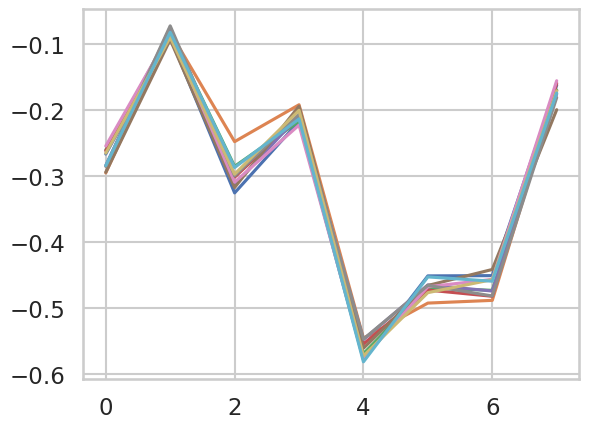

In [28]:
for i in range(10):
    plt.plot(eigenvector_list[i])
eigenvector_list[i]

In [29]:
rw_mean = rw_list.mean(0)
rw_std = rw_list.std(0)

rw_real_mean = rw_real_list.mean(0)
rw_real_std = rw_real_list.std(0)

rw_train_mean = rw_train_list.mean(0)
rw_train_std = rw_train_list.std(0)

rw_real_train_mean = rw_real_train_list.mean(0)
rw_real_train_std = rw_real_train_list.std(0)

rw_sum_mean = np.nanmean(rw_sum_list, axis=0)
rw_sum_std = np.nanstd(rw_sum_list, axis=0)
rw_diff_mean = np.nanmean(rw_diff_list, axis=0)
rw_diff_std = np.nanstd(rw_diff_list, axis=0)
rw_lr_mean = np.nanmean(rw_lr_list, axis=0)
rw_lr_std = np.nanstd(rw_lr_list, axis=0)

cp_mean = np.nanmean(cp_list,axis=0)
cp_std = np.nanstd(cp_list, axis=0)

cp_train_mean = np.nanmean(cp_train_list, axis=0)
cp_train_std = np.nanstd(cp_train_list, axis=0)

#cp_real_mean = cp_real_list.mean(0)
#cp_real_std = cp_real_list.std(0)

cp_real_train_mean = np.nanmean(cp_real_train_list, axis=0)
cp_real_train_std = np.nanstd(cp_real_train_list, axis=0)

cp_sum_mean = np.nanmean(cp_sum_list, axis=0)
cp_sum_std = np.nanstd(cp_sum_list, axis=0)
cp_diff_mean = np.nanmean(cp_diff_list, axis=0)
cp_diff_std = np.nanstd(cp_diff_list, axis=0)
cp_lr_mean = np.nanmean(cp_lr_list, axis=0)
cp_lr_std = np.nanstd(cp_lr_list, axis=0)

weight_mean = weight_list.mean(0)
weight_std = weight_list.std(0)


Text(0.5, 1.0, 'mean weights')

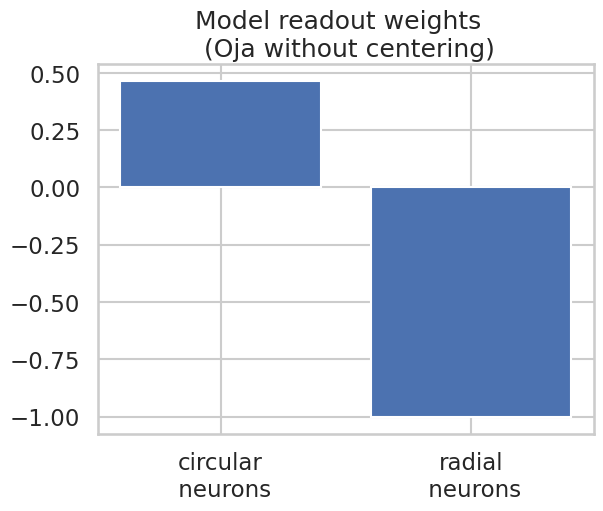

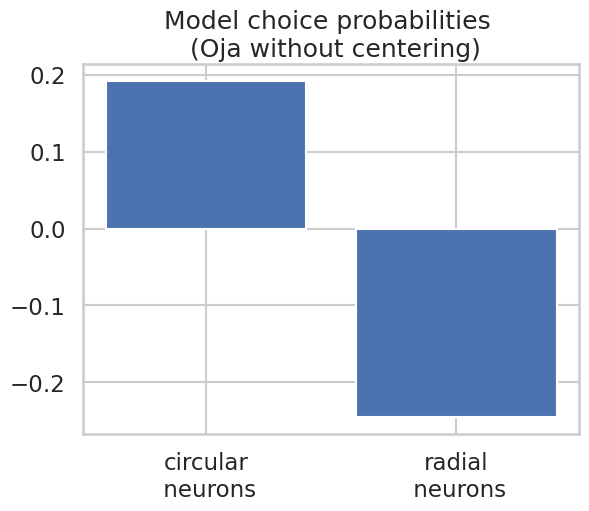

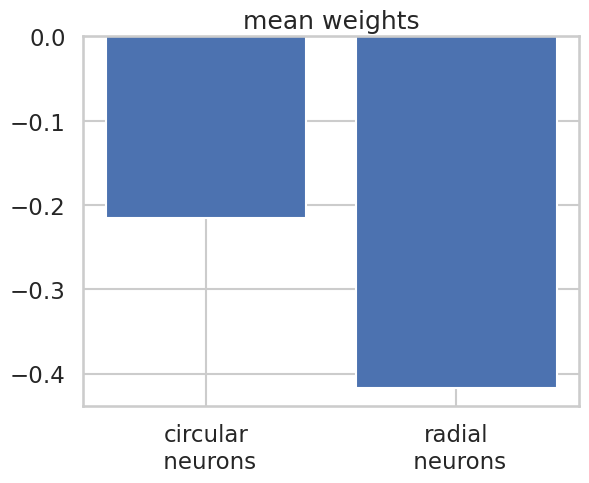

In [30]:
plt.bar(["circular\n neurons", "radial\n neurons"], [rw_mean[:len(tuned_circ)].mean(), rw_mean[len(tuned_circ):].mean()])#, yerr=[np.nanstd(rw_list[:, :len(tuned_circ)].mean(1)), np.nanstd(rw_list[:, len(tuned_circ):].mean(1))]) #yerr=[rw_std[:len(tuned_circ)].mean(), rw_std[len(tuned_circ):].mean()])
plt.title("Model readout weights  \n (Oja without centering)")

plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [cp_mean[:len(tuned_circ)].mean()-0.5, cp_mean[len(tuned_circ):].mean()-0.5]) #, yerr=[np.nanstd(cp_list[:, :len(tuned_circ)].mean(1)), np.nanstd(cp_list[:, len(tuned_circ):].mean(1))]) #yerr=[cp_std[:len(tuned_circ)].mean(), cp_std[len(tuned_circ):].mean()])
plt.title("Model choice probabilities \n (Oja without centering)")

plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [weight_mean[:len(tuned_circ)].mean(), weight_mean[len(tuned_circ):].mean()])
plt.title("mean weights")

Text(0.5, 1.0, 'Model choice probabilities \n(Oja, with centering)')

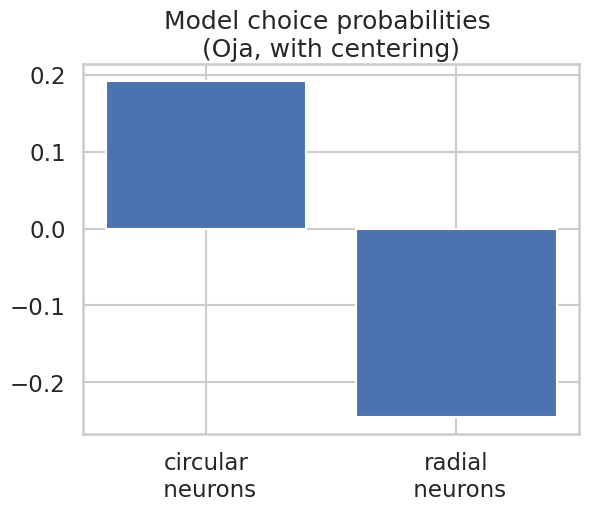

In [31]:
plt.bar(["circular\n neurons", "radial\n neurons"], [cp_mean[:len(tuned_circ)].mean()-0.5, cp_mean[len(tuned_circ):].mean()-0.5])#, yerr=[cp_std[:len(tuned_circ)].mean(), cp_std[len(tuned_circ):].mean()])
#plt.title("readout weights (test)")
plt.title("Model choice probabilities \n(Oja, with centering)")

<BarContainer object of 2 artists>

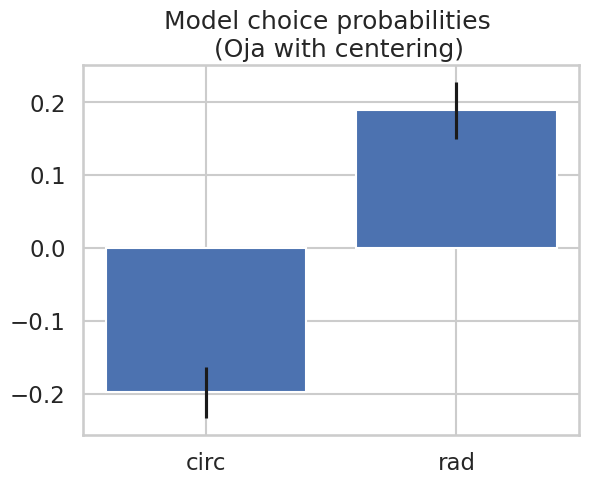

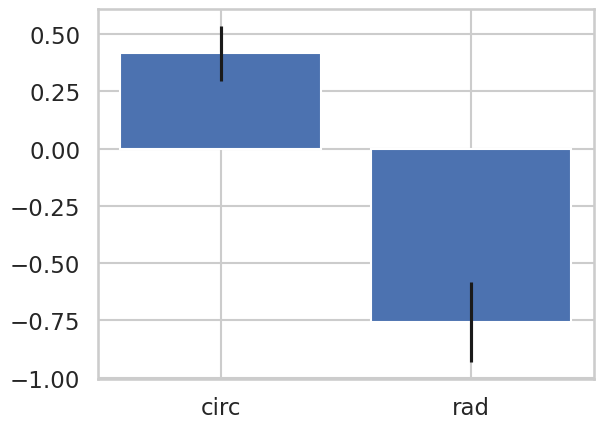

In [32]:
plt.figure()
plt.bar(["circ", "rad"], [-cp_train_mean[:len(tuned_circ)].mean()+0.5, -cp_train_mean[len(tuned_circ):].mean()+0.5], yerr=[cp_train_std[:len(tuned_circ)].mean(), cp_train_std[len(tuned_circ):].mean()])
plt.title("Model choice probabilities \n  (Oja with centering)")

plt.figure()
plt.bar(["circ", "rad"], [rw_train_mean[:len(tuned_circ)].mean(), rw_train_mean[len(tuned_circ):].mean()], yerr=[rw_train_std[:len(tuned_circ)].mean(), rw_train_std[len(tuned_circ):].mean()])


Text(0.5, 1.0, 'Model choice probabilities \n (Oja with centering)')

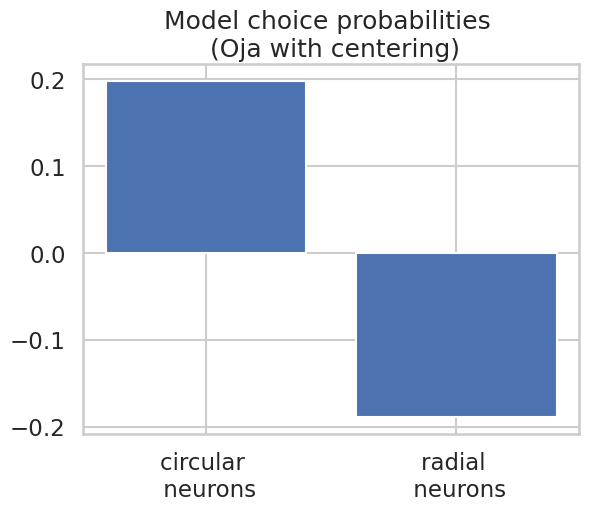

In [33]:
plt.figure()
plt.bar(["circular \n neurons", "radial \n neurons"], [cp_train_mean[:len(tuned_circ)].mean()-0.5, cp_train_mean[len(tuned_circ):].mean()-0.5])#, yerr=[cp_train_std[:len(tuned_circ)].mean(), cp_train_std[len(tuned_circ):].mean()])
plt.title("Model choice probabilities \n (Oja with centering)")


In [34]:
#for i in range(len(cp_train_list)):
#    plt.figure()
#    plt.bar(["circ", "rad"], [cp_train_real_list[i, :len(tuned_circ)].mean()-0.5, cp_train_list[i, len(tuned_circ):].mean()-0.5])

Text(0.5, 1.0, 'Choice probabilities (data)')

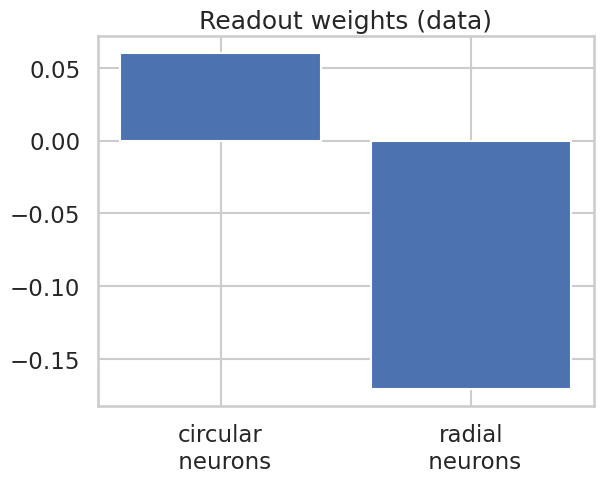

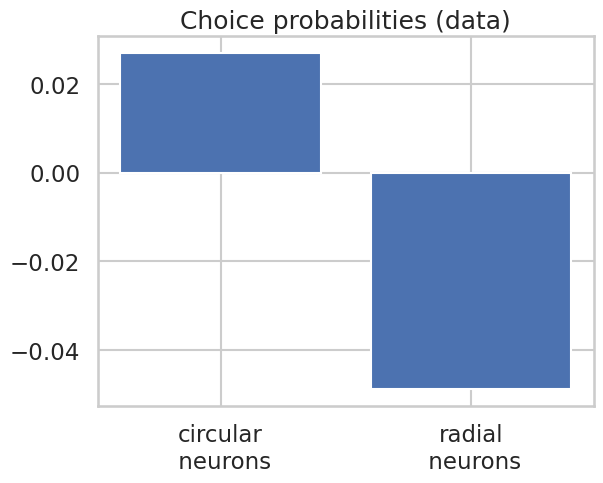

In [35]:
"""
plt.figure()
plt.bar(["circ", "rad"], [rw_real_mean[:3].mean(), rw_real_mean[-1]])
plt.title("readout weights REAL (test)")

plt.figure()
plt.bar(["circ", "rad"], [cp_real_mean[:3].mean()-0.5, cp_real_mean[-1]-0.5])
plt.title("choice probability REAL (test)")
"""
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [rw_real_train_mean[:len(tuned_circ)].mean(), rw_real_train_mean[len(tuned_circ):].mean()], yerr=[rw_real_train_std[:len(tuned_circ)].mean(), rw_real_train_std[len(tuned_circ):].mean()])
plt.title("Readout weights (data)")

plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [cp_real_train_mean[:len(tuned_circ)].mean()-0.5, cp_real_train_mean[len(tuned_circ):].mean()-0.5], yerr=[cp_real_train_std[:len(tuned_circ)].mean(), cp_real_train_std[len(tuned_circ):].mean()])
plt.title("Choice probabilities (data)")

Text(0.5, 1.0, 'Readout weights (data)')

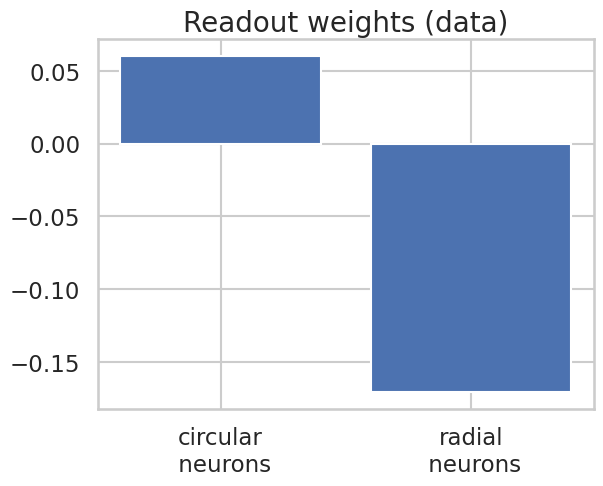

In [36]:
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [rw_real_train_mean[:len(tuned_circ)].mean(), rw_real_train_mean[len(tuned_circ):].mean()], yerr=[rw_real_train_std[:len(tuned_circ)].mean(), rw_real_train_std[len(tuned_circ):].mean()])
plt.title("Readout weights (data)", fontsize=20)

Text(0.5, 1.0, 'Choice probabilities (data)')

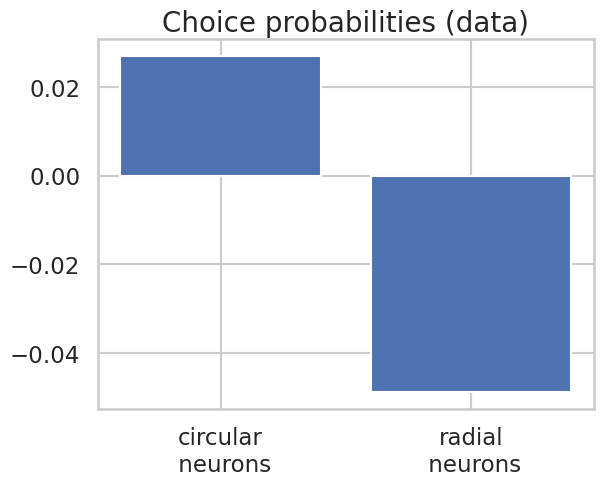

In [37]:
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [cp_real_train_mean[:len(tuned_circ)].mean()-0.5, cp_real_train_mean[len(tuned_circ):].mean()-0.5])
plt.title("Choice probabilities (data)", fontsize=20)


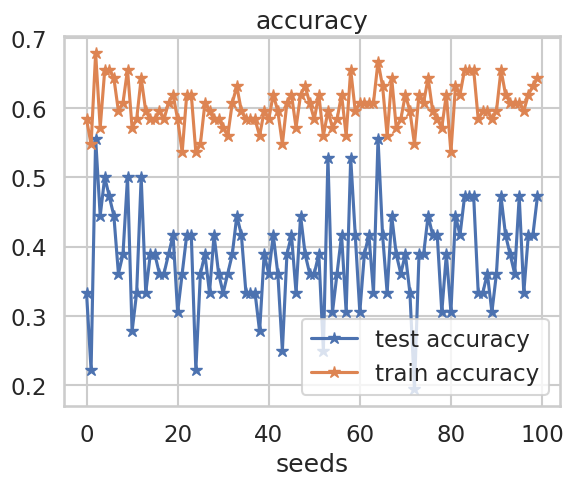

In [38]:
plt.plot(acc_list, "*-")
plt.plot(acc_training_list, "*-")
plt.xlabel("seeds")
plt.title("accuracy")
plt.legend(["test accuracy", "train accuracy"])

Text(0.5, 1.0, 'Class imbalance (Oja)')

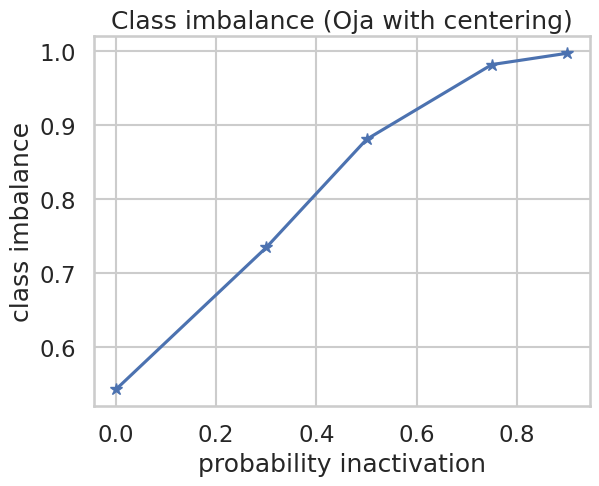

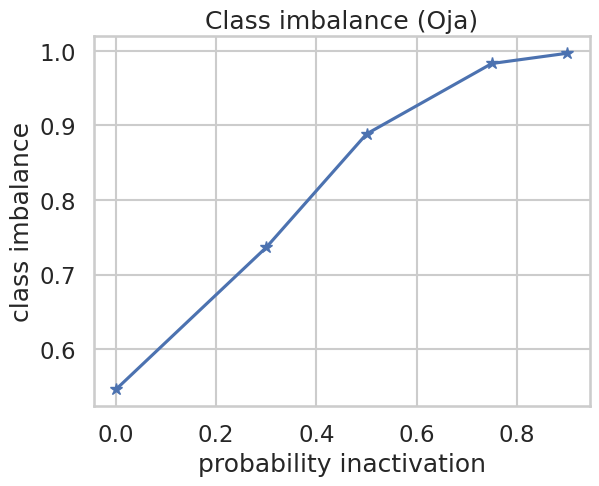

In [39]:

p_inactivation = [.00001, 0.3, 0.5, 0.75, 0.9]

plt.figure()
plt.plot(p_inactivation, class_imbalance_list.mean(0), "*-")
plt.xlabel("probability inactivation")
plt.ylabel("class imbalance")
plt.title("Class imbalance (Oja with centering)")

plt.figure()
plt.plot(p_inactivation, class_imbalance_train_list.mean(0), "*-")
plt.xlabel("probability inactivation")
plt.ylabel("class imbalance")
plt.title("Class imbalance (Oja)")

Text(0.5, 1.0, 'Class imbalance (Oja without centering)')

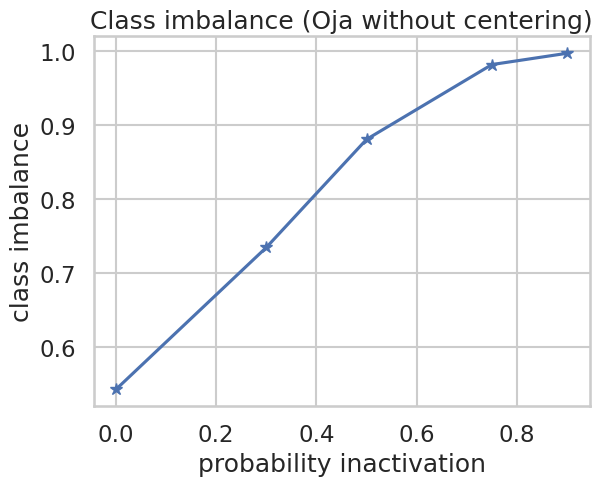

In [40]:
plt.figure()
plt.plot(p_inactivation, class_imbalance_list.mean(0), "*-")
plt.xlabel("probability inactivation")
plt.ylabel("class imbalance")
plt.title("Class imbalance (Oja without centering)")


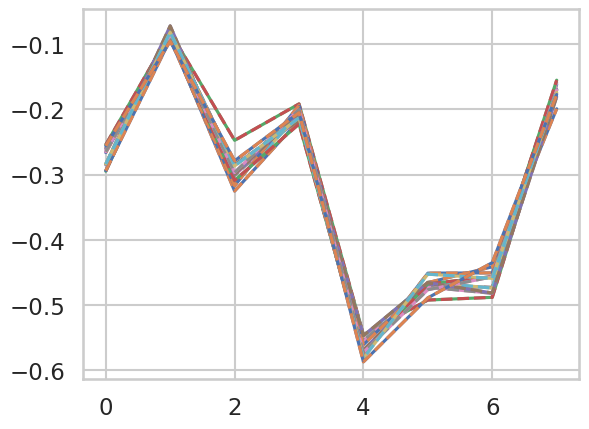

In [41]:
for i in range(11):
    plt.plot(weight_list[i,:])
    plt.plot(eigenvector_list[i,:], "--")

'\nplt.figure()\nplt.bar(["circular\n neurons", "radial\n neurons"], [rw_sum_mean[:len(tuned_circ)].mean(), rw_sum_mean[len(tuned_circ):].mean()])\n#plt.title("readout weights (test)")\nplt.title("Sum model readout weights")\n'

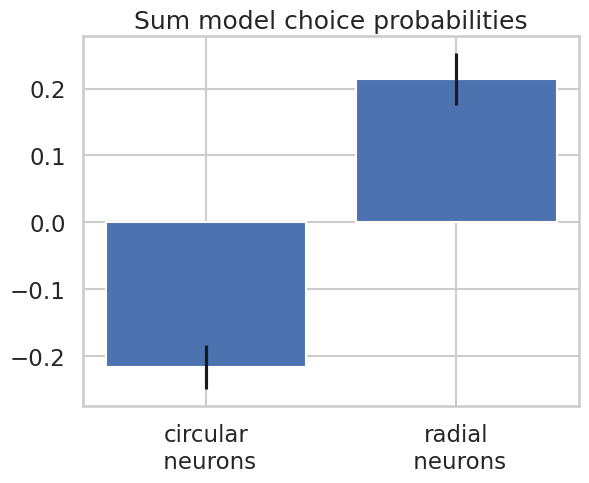

In [42]:
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [-cp_sum_mean[:len(tuned_circ)].mean()+0.5, -cp_sum_mean[len(tuned_circ):].mean()+0.5], yerr=[cp_sum_std[:len(tuned_circ)].mean(), cp_sum_std[len(tuned_circ):].mean()])
#plt.title("readout weights (test)")
plt.title("Sum model choice probabilities")

"""
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [rw_sum_mean[:len(tuned_circ)].mean(), rw_sum_mean[len(tuned_circ):].mean()])
#plt.title("readout weights (test)")
plt.title("Sum model readout weights")
"""

'\nplt.figure()\nplt.bar(["circular\n neurons", "radial\n neurons"], [rw_diff_mean[:len(tuned_circ)].mean(), rw_diff_mean[len(tuned_circ):].mean()])\n#plt.title("readout weights (test)")\nplt.title("Diff model readout weights")\n'

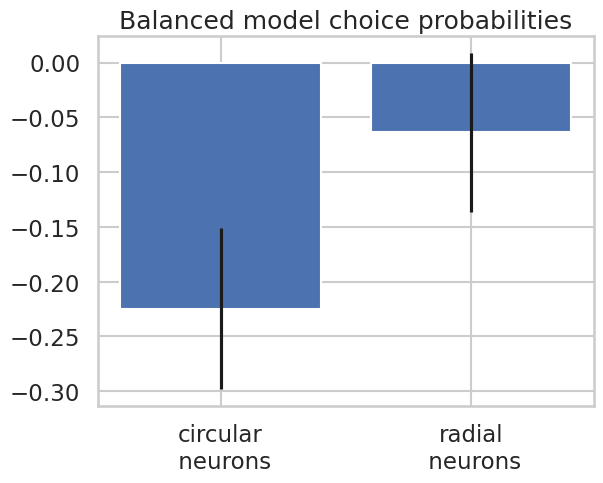

In [43]:
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [-cp_diff_mean[:len(tuned_circ)].mean()+0.5, -cp_diff_mean[len(tuned_circ):].mean()+0.5], yerr=[cp_diff_std[:len(tuned_circ)].mean(), cp_diff_std[len(tuned_circ):].mean()])
#plt.title("readout weights (test)")
plt.title("Balanced model choice probabilities")
"""
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [rw_diff_mean[:len(tuned_circ)].mean(), rw_diff_mean[len(tuned_circ):].mean()])
#plt.title("readout weights (test)")
plt.title("Diff model readout weights")
"""

'\nplt.figure()\nplt.bar(["circular\n neurons", "radial\n neurons"], [rw_lr_mean[:len(tuned_circ)].mean(), rw_lr_mean[len(tuned_circ):].mean()])\n#plt.title("readout weights (test)")\nplt.title("Diff model readout weights")\n'

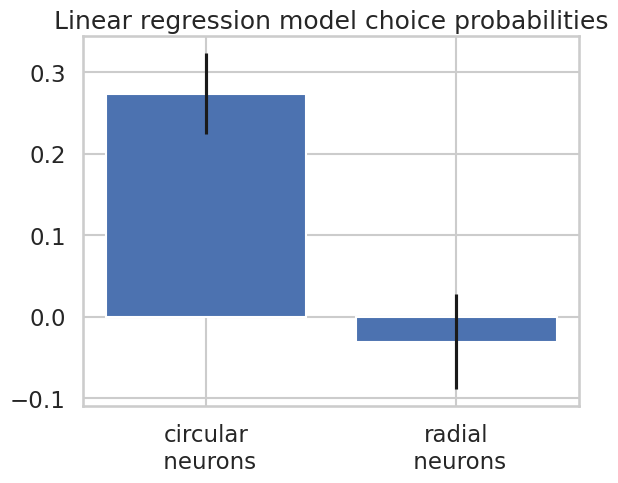

In [44]:
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [cp_lr_mean[:len(tuned_circ)].mean()-0.5, cp_lr_mean[len(tuned_circ):].mean()-0.5], yerr=[cp_lr_std[:len(tuned_circ)].mean(), cp_lr_std[len(tuned_circ):].mean()])
#plt.title("readout weights (test)")
plt.title("Linear regression model choice probabilities")

"""
plt.figure()
plt.bar(["circular\n neurons", "radial\n neurons"], [rw_lr_mean[:len(tuned_circ)].mean(), rw_lr_mean[len(tuned_circ):].mean()])
#plt.title("readout weights (test)")
plt.title("Diff model readout weights")
"""

In [45]:
monkey = "M1"
phase = 1
stim = "Lf" #"Hf"

date_dir = "2026-07-07/"
centering = True

rw_center_list = []
rw_train_center_list = []
cp_center_list = []
cp_train_center_list = []
class_imbalance_center_list = []
class_imbalance_train_center_list = []
eigenvector_center_clist = []
weight_center_list = []
acc_center_list = []
acc_training_center_list = []

for seed in range(1,101):
    tuned_rad = np.load('results/' + date_dir + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_' + snr_choice_list + '_choice_' + choice + ["_centering" if centering else ""][0] + 'session_' + str(session) + '_neurons_tuned_rad' + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +'.npy')
    tuned_circ = np.load('results/' + date_dir + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_seed_' + str(seed) + '_snr_choice_' + snr_choice_list + '_choice_' + choice + ["_centering" if centering else ""][0] + 'session_' + str(session) + '_neurons_tuned_circ' + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +'.npy')

    rw = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] + ".npy")
    if rw.size == len(tuned_circ) + len(tuned_rad): rw_center_list.append(rw)
   
    cp = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    if cp.size == len(tuned_circ) + len(tuned_rad): cp_center_list.append(cp)
      
    rw_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_readout_weights_train" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    cp_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_cp_train" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    if rw_train.size == len(tuned_circ) + len(tuned_rad): rw_train_center_list.append(rw_train)
    if cp_train.size == len(tuned_circ) + len(tuned_rad): cp_train_center_list.append(cp_train)
    print(seed, cp_train, cp_real_train)

    eigenvector = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_eigenvector_vh" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    eigenvector_center_clist.append(eigenvector)
    
    weight = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_weight" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    weight_center_list.append(weight)

    acc = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_acc" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    acc_training = np.load('results/' + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + choice + ["_centering" if centering else ""][0] + "session_" + str(session) + "_acc_training" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    acc_center_list.append(acc); acc_training_center_list.append(acc_training)
    print("acc", acc, acc_training)
    
    class_imbalance = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" + str(choice) + ["_centering" if centering else ""][0] + "session_" + str(session) + "_class_imbalance" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    class_imbalance_train = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim +"_gratings_seed_" + str(seed) + "_snr_choice_" + snr_choice_list + "_choice_" +  str(choice) +  ["_centering" if centering else ""][0] +"session_" + str(session) + "_class_imbalance_train" + ["_lC" if LC else ""][0] + ["_nonlinear" if nonlinear else ""][0] +".npy")
    
    class_imbalance_center_list.append(class_imbalance)
    class_imbalance_train_center_list.append(class_imbalance_train)
  

1 [0.68879051 0.62302925 0.93207273 0.55199368 0.30579447] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.3333333333333333 0.5714285714285714
2 [0.63157576 0.53312576 0.96370606 0.51520758 0.35098636] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.25 0.5595238095238095
3 [0.6451049  0.61206294 0.9701049  0.50655594 0.38994755] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.5555555555555556 0.6190476190476191
4 [0.62332418 0.55391484 0.95446429 0.45322802 0.40994505] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.4444444444444444 0.5476190476190477
5 [0.69474313 0.59080048 0.92592593 0.49641577 0.24253286] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.5 0.6190476190476191
6 [0.73342864 0.65737048 0.9227566  0.6174218  0.30893695] [0.5884629  0.45888788 0.47864993 0.5817075  0.45112422]
acc 0.4722222222222222 0.6309523809523809
7 [0.64481667 0.52293333 0.96591667 0.500375   0.365775  ] [0.5884629  0.45888788

In [46]:
rw_center_list = np.stack(rw_center_list)
rw_train_center_list = np.stack(rw_train_center_list)
cp_center_list = np.stack(cp_center_list)
cp_train_center_list = np.stack(cp_train_center_list)
class_imbalance_center_list = np.stack(class_imbalance_center_list)
class_imbalance_train_center_list = np.stack(class_imbalance_train_center_list)
eigenvector_center_clist = np.stack(eigenvector_center_clist)
weight_center_list = np.stack(weight_center_list)
acc_center_list = np.stack(acc_center_list)
acc_training_center_list = np.stack(acc_training_center_list)

rw_center_mean = np.nanmean(rw_center_list, axis=0)
rw_center_std = np.nanstd(rw_center_list, axis=0)
rw_train_center_mean = np.nanmean(rw_train_center_list, axis=0)
rw_train_center_std = np.nanstd(rw_train_center_list, axis=0)
cp_center_mean = np.nanmean(cp_center_list, axis=0)
cp_center_std = np.nanstd(cp_center_list, axis=0)
cp_train_center_mean = np.nanmean(cp_train_center_list, axis=0)
cp_train_center_std = np.nanstd(cp_train_center_list, axis=0)
class_imbalance_center_mean = np.nanmean(class_imbalance_center_list, axis=0)
class_imbalance_center_std = np.nanstd(class_imbalance_center_list, axis=0)
class_imbalance_train_center_mean = np.nanmean(class_imbalance_train_center_list, axis=0)
class_imbalance_train_center_std = np.nanstd(class_imbalance_train_center_list, axis=0)


cp_mean_center_circ = cp_center_mean[:len(tuned_circ)].mean()-0.5
cp_mean_center_rad = cp_center_mean[:len(tuned_rad)].mean()-0.5
cp_mean_train_center_circ = cp_train_center_mean[:len(tuned_circ)].mean()-0.5
cp_mean_train_center_rad = cp_train_center_mean[:len(tuned_rad)].mean()-0.5

rw_mean_center_circ = rw_center_mean[:len(tuned_circ)].mean()-0.5
rw_mean_center_rad = rw_center_mean[:len(tuned_rad)].mean()-0.5
rw_mean_train_center_circ = rw_train_center_mean[:len(tuned_circ)].mean()-0.5
rw_mean_train_center_rad = rw_train_center_mean[:len(tuned_rad)].mean()-0.5


In [47]:
cp_mean_circ = cp_mean[:len(tuned_circ)].mean()-0.5
cp_mean_rad = cp_mean[len(tuned_circ):].mean()-0.5
cp_real_mean_circ = cp_real_train_mean[:len(tuned_circ)].mean()-0.5
cp_real_mean_rad = cp_real_train_mean[len(tuned_circ):].mean()-0.5
cp_sum_mean_circ = cp_sum_mean[:len(tuned_circ)].mean() -0.5
cp_sum_mean_rad = cp_sum_mean[len(tuned_circ):].mean() -0.5
cp_diff_mean_circ = cp_diff_mean[:len(tuned_circ)].mean() -0.5
cp_diff_mean_rad = cp_diff_mean[len(tuned_circ):].mean() -0.5
cp_lr_mean_circ = cp_lr_mean[:len(tuned_circ)].mean() -0.5
cp_lr_mean_rad = cp_lr_mean[len(tuned_circ):].mean() -0.5
#cp_gd_mean_circ = cp_gd_mean[:len(tuned_circ)].mean() -0.5
#cp_gd_mean_rad = cp_gd_mean[len(tuned_circ):].mean() -0.5

factor = np.abs(0.5*cp_real_mean_circ/cp_mean_circ + 0.5*cp_real_mean_rad/cp_mean_rad)
print("Oja (w/o centering) model diff: ", 0.5*(np.abs(factor*cp_mean_circ - cp_real_mean_circ) + np.abs(factor*cp_mean_rad - cp_real_mean_rad)))
factor = np.abs(0.5*cp_real_mean_circ/cp_mean_center_circ + 0.5*cp_real_mean_rad/cp_mean_center_rad)
print("Oja (w/ centering) model diff: ", 0.5*(np.abs(factor*cp_mean_center_circ - cp_real_mean_circ) + np.abs(factor*cp_mean_center_rad - cp_real_mean_rad)))
factor = np.abs(0.5*cp_real_mean_circ/cp_sum_mean_circ + 0.5*cp_real_mean_rad/cp_sum_mean_rad)
print("SUM model diff: ", 0.5*(np.abs(factor*cp_sum_mean_circ - cp_real_mean_circ) + np.abs(factor*cp_sum_mean_rad - cp_real_mean_rad)))
factor = np.abs(0.5*cp_real_mean_circ/cp_diff_mean_circ + 0.5*cp_real_mean_rad/cp_diff_mean_rad)
print("DIFF model diff: ", 0.5*(np.abs(factor*cp_diff_mean_circ - cp_real_mean_circ) + np.abs(factor*cp_diff_mean_rad - cp_real_mean_rad)))
factor = np.abs(0.5*cp_real_mean_circ/cp_lr_mean_circ + 0.5*cp_real_mean_rad/cp_lr_mean_rad)
print("LR model diff: ", 0.5*(np.abs(factor*cp_lr_mean_circ - cp_real_mean_circ) + np.abs(factor*cp_lr_mean_rad - cp_real_mean_rad)))
#factor = np.abs(0.5*cp_real_mean_circ/cp_gd_mean_circ + 0.5*cp_real_mean_rad/cp_gd_mean_rad)
#print("GD diff: ", 0.5*(np.abs(factor*cp_gd_mean_circ - cp_real_mean_circ) + np.abs(factor*cp_gd_mean_rad - cp_real_mean_rad)))


Oja (w/o centering) model diff:  0.006402066610669142
Oja (w/ centering) model diff:  0.03639325601265124
SUM model diff:  0.011226817194843749
DIFF model diff:  0.057610946937553836
LR model diff:  0.11280895630394792


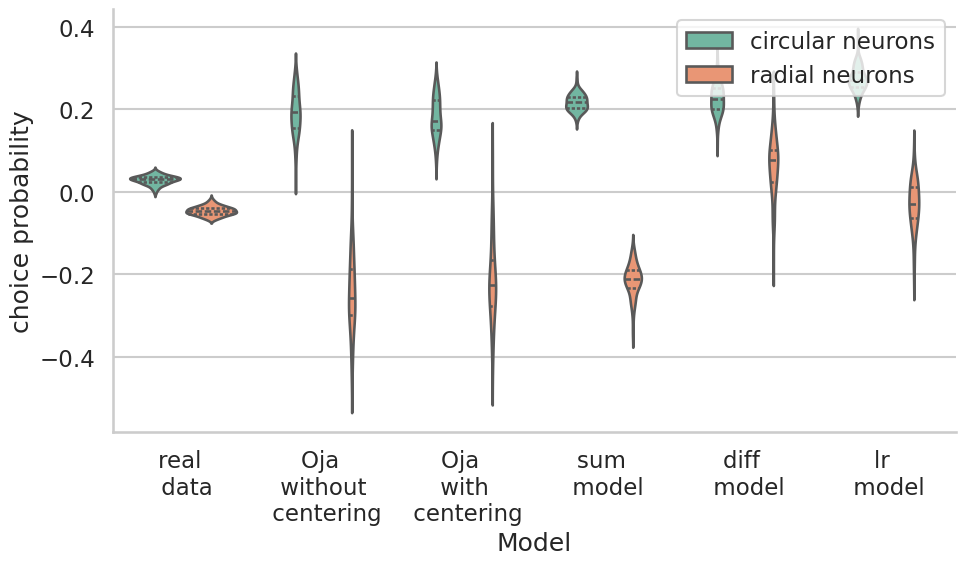

In [50]:
#gradient descent

In [89]:
monkey = "M1"
phase = 1
stim =  "Lf" #"Lf"

snr_choice = 0.8
snr_choice_list = [0.65, 0.8, 1.0] #[0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0]
choice = "only_session"
session = 10
centering = False
nonlinear = True

date_dir = "2026-07-30/"

readout_weight_gd_list = []
class_imbalance_gd_list = []
cp_gd_list = []
w_gd_list = []
b_gd_list = []
for seed in range(1,101):
        try:
            readout_weights = np.load("results/" + date_dir + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + ["_centering" if centering else ""][0] + ["_nonlinear" if nonlinear else ""][0] + "_readout_weights.npy")
            class_imbalance = np.load("results/" + date_dir  + monkey + "_Phase" + str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + ["_centering" if centering else ""][0] + ["_nonlinear" if nonlinear else ""][0] + "_class_imbalance.npy")
            cp = np.load("results/" + date_dir  + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + ["_centering" if centering else ""][0] + ["_nonlinear" if nonlinear else ""][0] + "_cp.npy")
            
            w_gd = np.load("results/" + date_dir  + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + ["_centering" if centering else ""][0] + ["_nonlinear" if nonlinear else ""][0] + "w_gd.npy")
            b_gd = np.load("results/" + date_dir  + monkey + "_Phase" +str(phase) + "_" + stim + "_gratings_GD_seed_" + str(seed) + "_snr_choice_" + str(snr_choice_list) + "_choice_" + choice + "_session"+ str(session) + ["_centering" if centering else ""][0] + ["_nonlinear" if nonlinear else ""][0] + "b_gd.npy")
            
            if (readout_weights != np.array('NaN')).sum() != 0:
                readout_weight_gd_list.append(readout_weights)
                cp_gd_list.append(cp)
            class_imbalance_gd_list.append(class_imbalance)
            w_gd_list.append(w_gd)
            b_gd_list.append(b_gd)

        except:
            continue

        tuned_rad = np.load('results/' + date_dir + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_GD_seed_' + str(30) + '_snr_choice_[0.65, 0.8, 1.0]_choice_' + choice + '_session' + str(session)  + ["_centering" if centering else ""][0]  + ["_nonlinear" if nonlinear else ""][0] + '_neurons_tuned_rad.npy')
        tuned_circ = np.load('results/' + date_dir + monkey + '_Phase' + str(phase) + '_' + stim + '_gratings_GD_seed_' + str(30) + '_snr_choice_[0.65, 0.8, 1.0]_choice_' + choice + '_session' + str(session) + ["_centering" if centering else ""][0]  + ["_nonlinear" if nonlinear else ""][0] + '_neurons_tuned_circ.npy')

readout_weight_gd_list = np.stack(readout_weight_gd_list)
class_imbalance_gd_list = np.stack(class_imbalance_gd_list)
cp_gd_list = np.stack(cp_gd_list)
w_gd_list = np.array(w_gd_list)
b_gd_list = np.array(b_gd_list)

In [90]:
readout_weight_gd_list.shape

(41, 5)

In [91]:
readout_weight_gd_mean = readout_weight_gd_list.mean(0)
readout_weight_gd_std = readout_weight_gd_list.std(0)

cp_gd_mean = cp_gd_list.mean(0)
cp_gd_std = cp_gd_list.std(0)

class_imbalance_gd_mean = class_imbalance_gd_list.mean(0)
class_imbalance_gd_std = class_imbalance_gd_list.std(0)

Text(0.5, 1.0, 'readout weights')

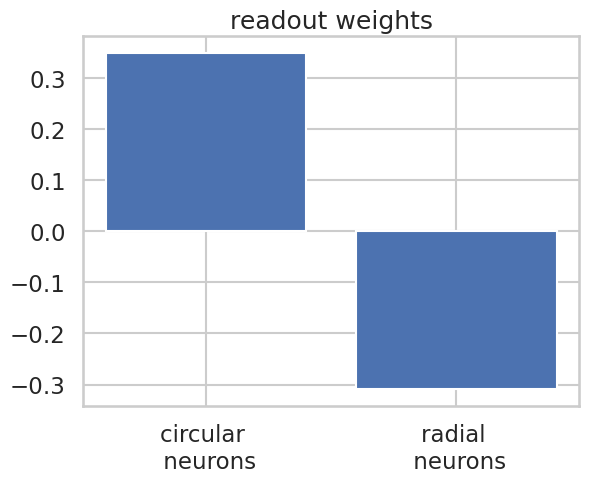

In [92]:
plt.bar(["circular \n neurons", "radial \n neurons"], [readout_weight_gd_mean[:len(tuned_circ)].mean(), readout_weight_gd_mean[len(tuned_circ):].mean()])
plt.title("readout weights")


Text(0.5, 1.0, 'Gradient descent choice probability')

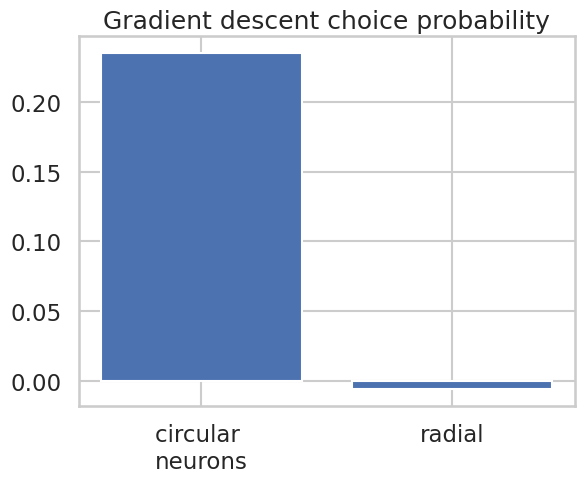

In [94]:
plt.figure()
plt.bar(["circular \nneurons", "radial"], [cp_gd_mean[:len(tuned_circ)].mean()-0.5, cp_gd_mean[len(tuned_circ):].mean()-0.5])
plt.title("Gradient descent choice probability")

Text(0.5, 1.0, 'class imbalance (gradient descent)')

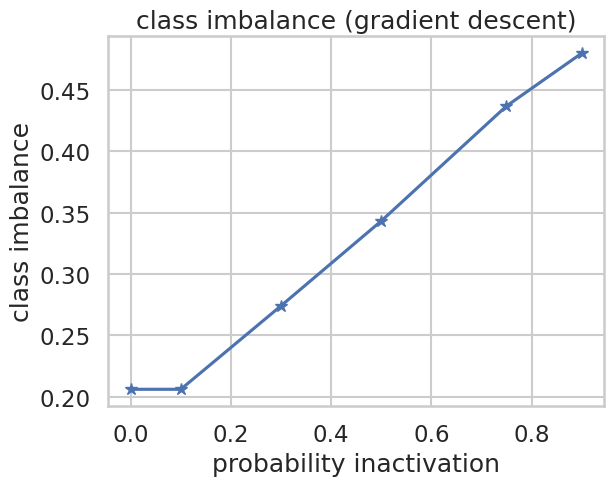

In [95]:
p_inactivation = [.00001, 0.1, 0.3, 0.5, 0.75, 0.9]

plt.figure()
plt.plot(p_inactivation, class_imbalance_gd_list.mean(0), "*-")
plt.xlabel("probability inactivation")
plt.ylabel("class imbalance")
plt.title("class imbalance (gradient descent)")

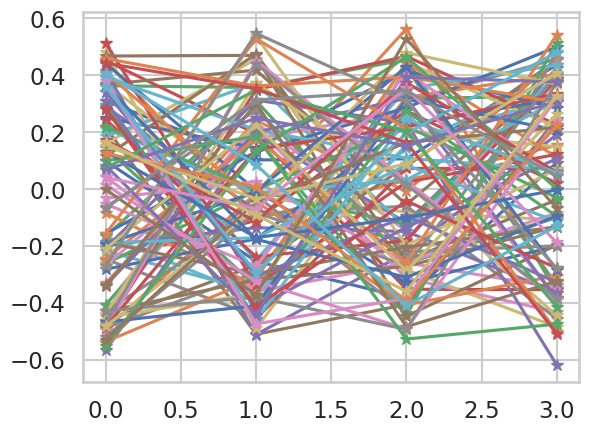

In [99]:
for i in range(len(w_gd_list)):
    plt.plot(w_gd_list[i,:].squeeze(), "*-")

Text(0, 0.5, 'biases')

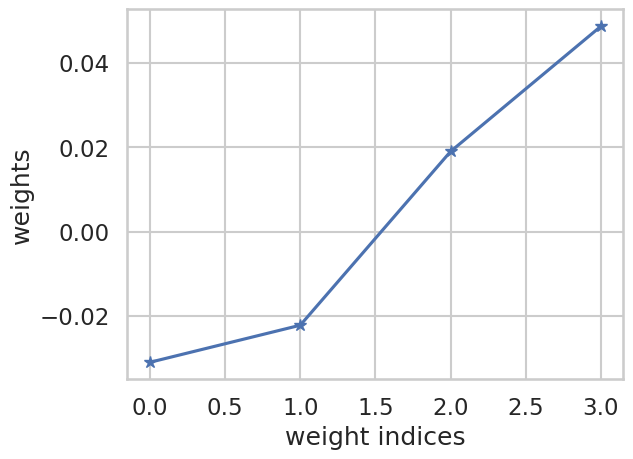

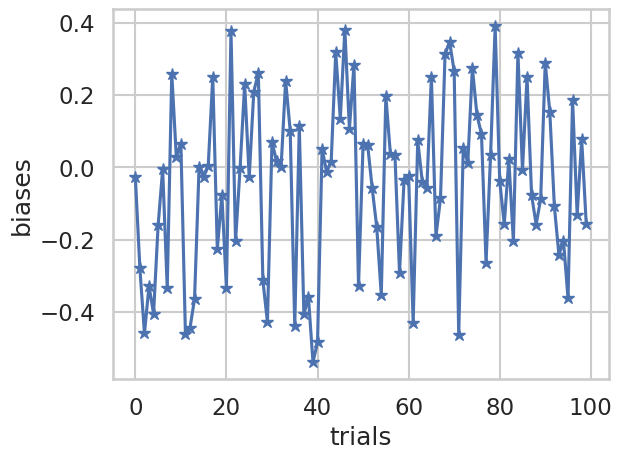

In [105]:
plt.plot(w_gd_list.squeeze().mean(0), "*-")
plt.xlabel("weight indices")
plt.ylabel("weights")

plt.figure()
plt.plot(b_gd_list, "*-")
plt.xlabel("trials")
plt.ylabel("biases")

/tmp/ipykernel_1922228/1357470778.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


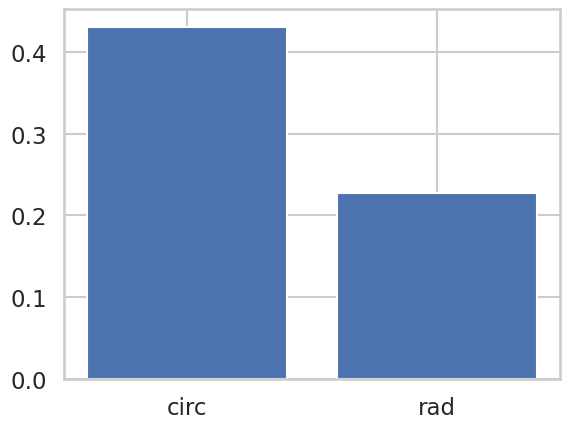

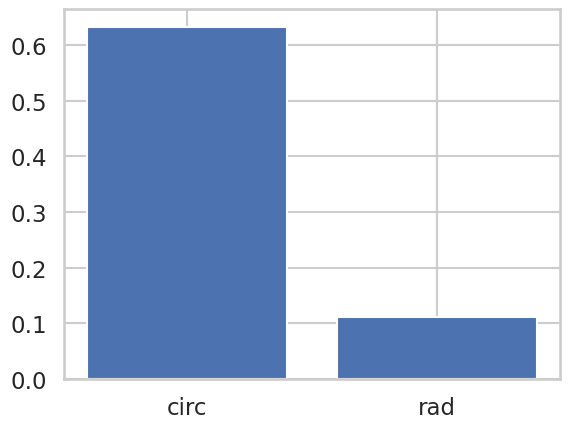

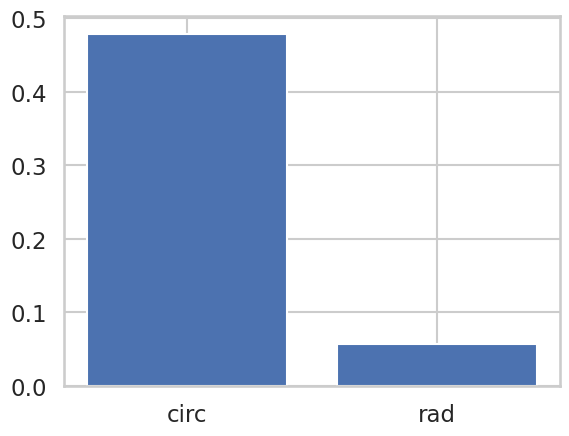

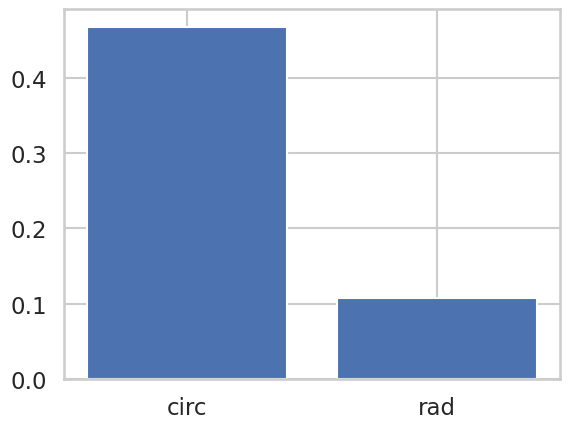

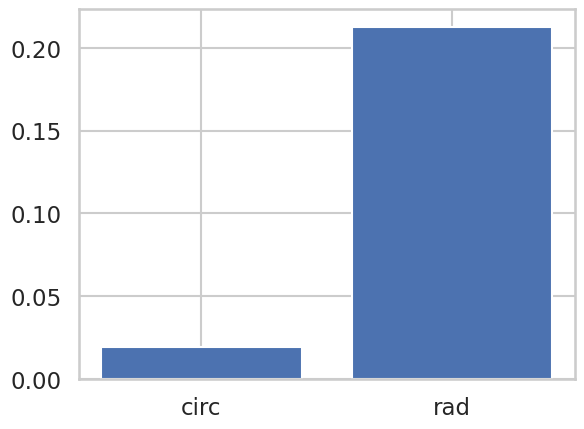

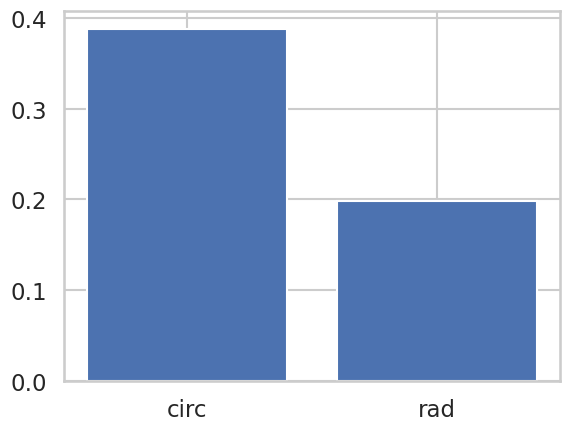

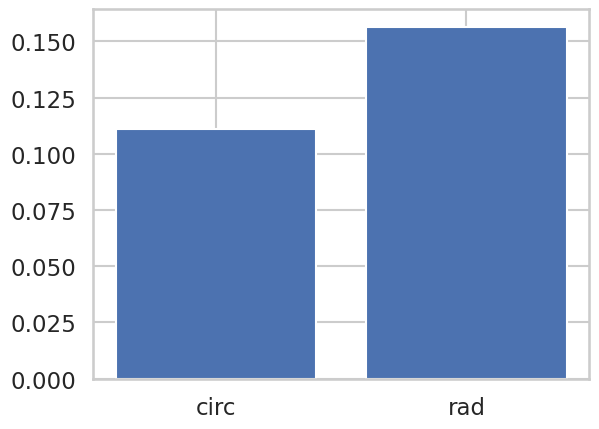

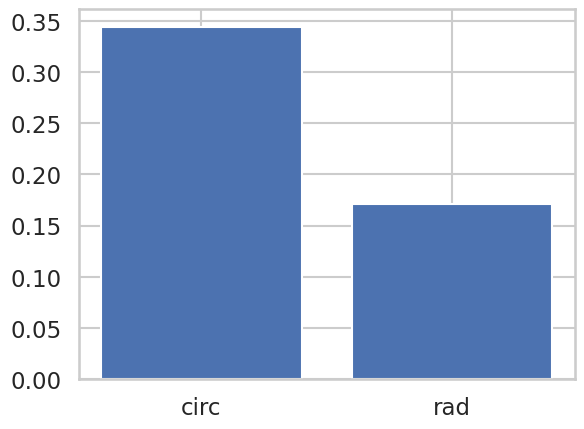

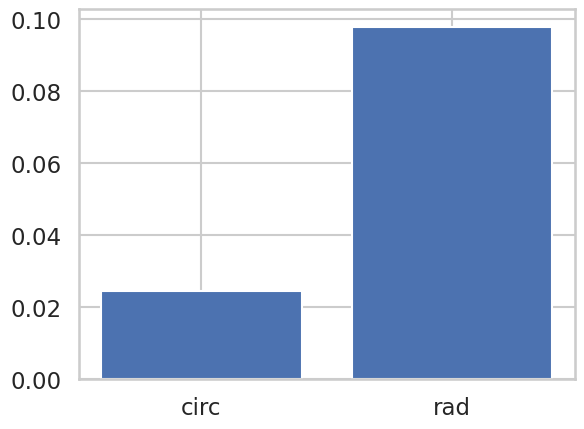

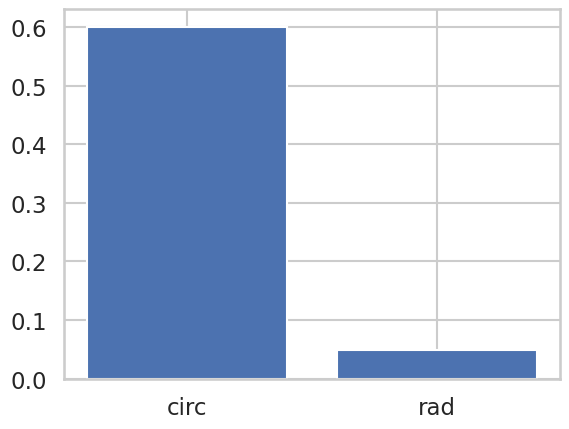

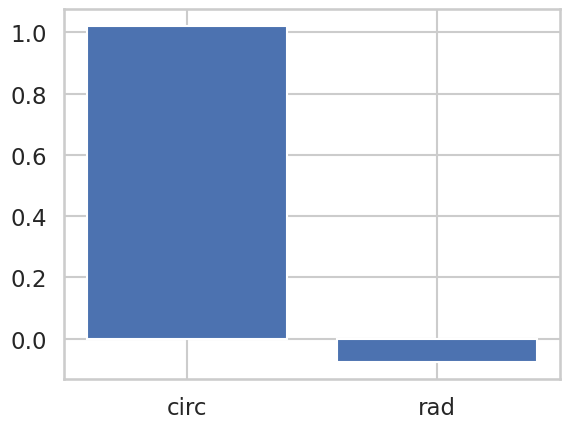

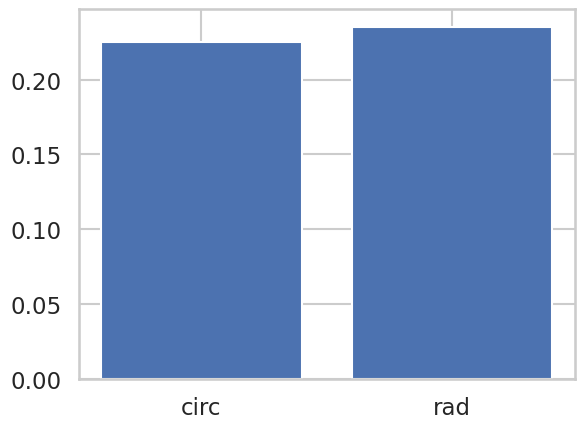

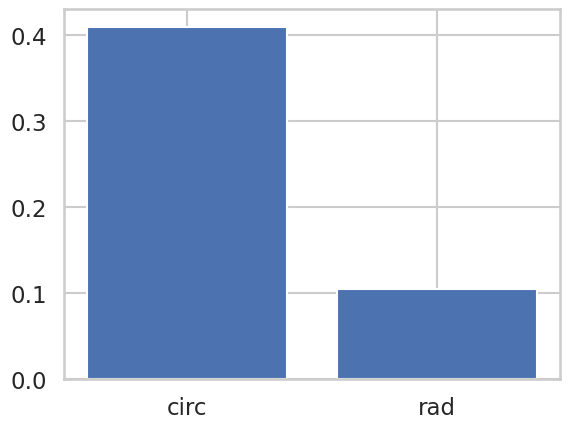

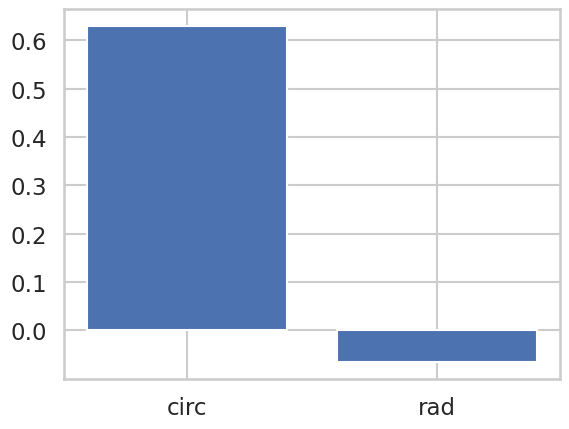

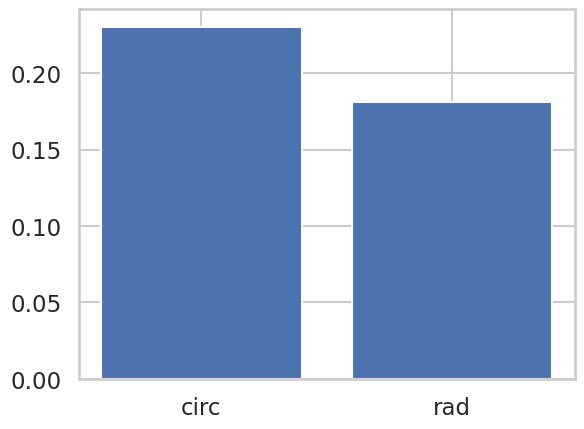

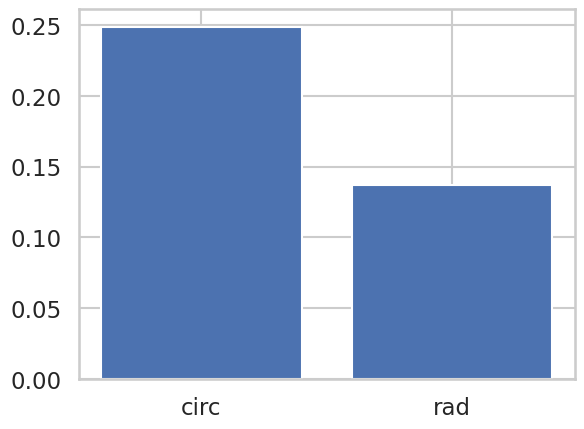

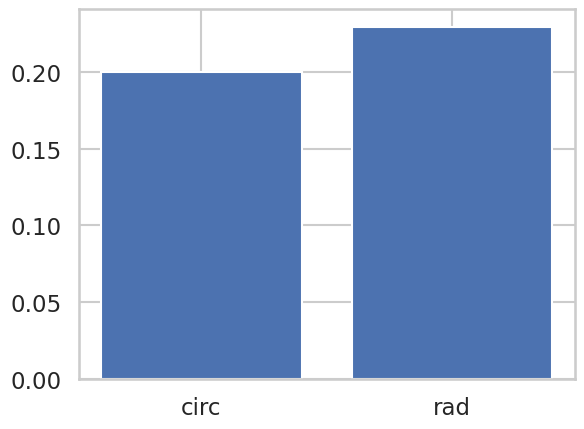

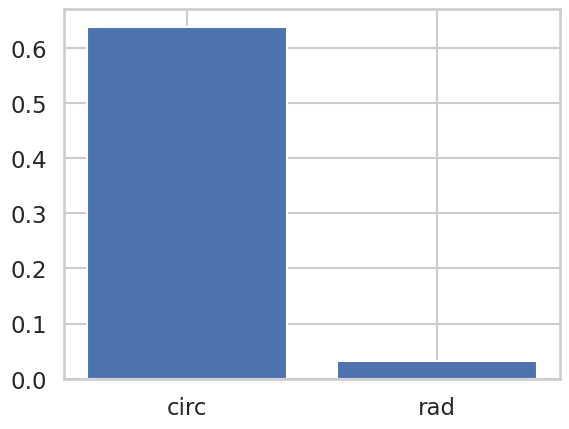

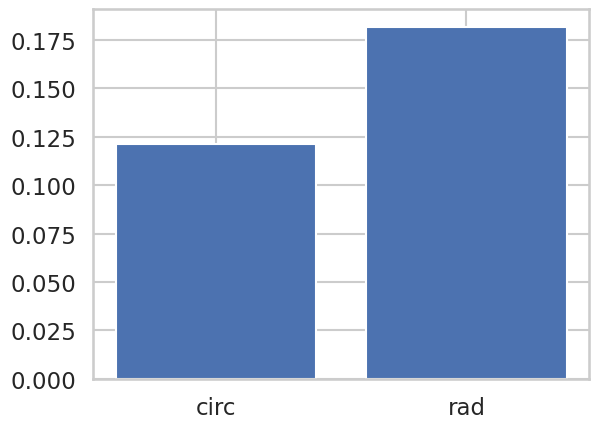

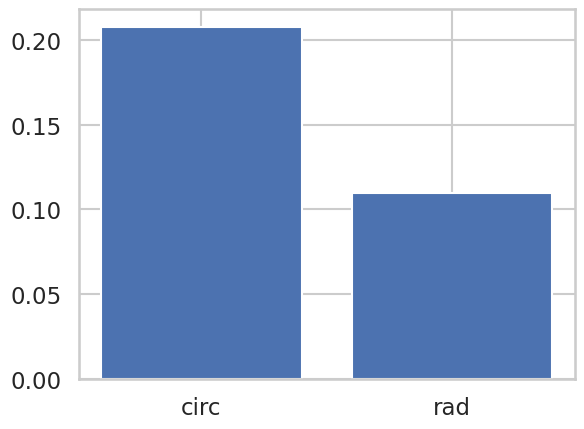

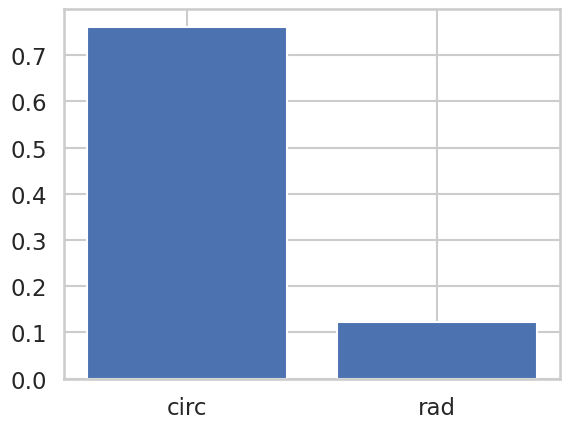

In [106]:
for i in range(len(rw_list)):
    plt.figure()
    plt.bar(["circ", "rad"], [rw_list[i,:1].mean(), rw_list[i,1:].mean()])

    if i == 20:
        break

In [ ]:
rw_real_train_list

In [ ]:
#plot fancy seaborn plot with models next to each other

In [87]:
#create dict
cp_results = {}
cp_results["real \n data"] = [cp_real_train_list[:,:len(tuned_circ)].mean(1)-0.5, cp_real_train_list[:,len(tuned_circ):].mean(1)-0.5]
cp_results["Oja \n without \n centering"] = [cp_list[:,:len(tuned_circ)].mean(1)-0.5, cp_list[:,len(tuned_circ):].mean(1)-0.5]
cp_results["Oja \n with \n centering"] = [cp_center_list[:,:len(tuned_circ)].mean(1)-0.5, cp_center_list[:,len(tuned_circ):].mean(1)-0.5]
cp_results["sum \n model"] = [cp_sum_list[:,:len(tuned_circ)].mean(1)-0.5, cp_sum_list[:,len(tuned_circ):].mean(1)-0.5]
cp_results["diff \n model"] = [cp_diff_list[:,:len(tuned_circ)].mean(1)-0.5, cp_diff_list[:,len(tuned_circ):].mean(1)-0.5]
cp_results["lr \n model"] = [cp_lr_list[:,:len(tuned_circ)].mean(1)-0.5, cp_lr_list[:,len(tuned_circ):].mean(1)-0.5]
cp_results["gradient \n descent \n model"] = [cp_gd_list[:,:len(tuned_circ)].mean(1)-0.5, cp_gd_list[:,len(tuned_circ):].mean(1)-0.5]

keys_cp_results = cp_results.keys()


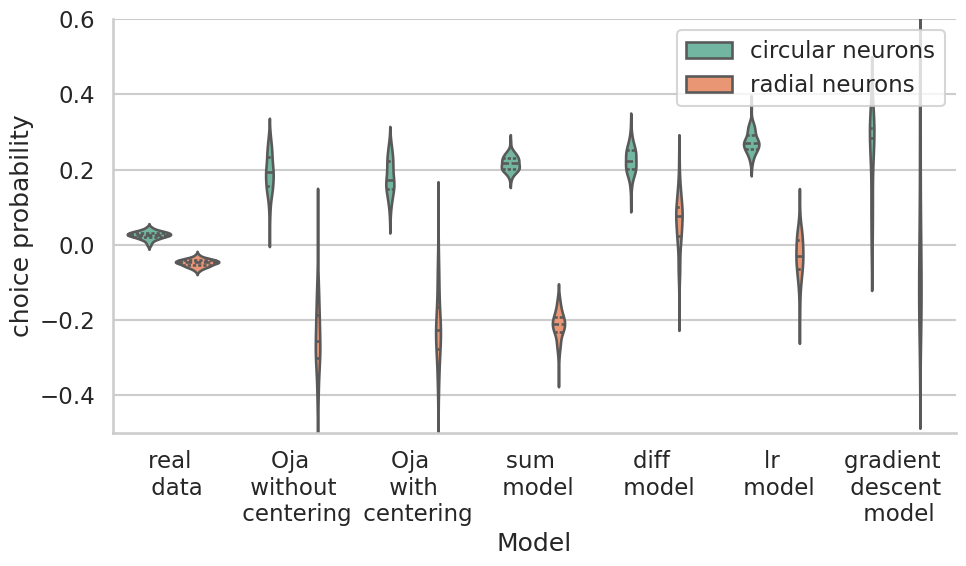

In [88]:
#fanc(ier) plot

records = []
for model in keys_cp_results:
    dist1 = cp_results[model][0]
    dist2 = cp_results[model][1]

    for v in dist1:
        if "real" in model: v += 0.01*np.random.randn(1)[0]
        records.append({'model': model, 'distribution': 'circular neurons', 'value': v})
    for v in dist2:
        if "real" in model: v += 0.01*np.random.randn(1)[0]
        records.append({'model': model, 'distribution': 'radial neurons', 'value': v})

df = pd.DataFrame(records)

# --- Plot ---
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=df,
    x='model',
    y='value',
    hue='distribution',
    split=False,       # set True if you want mirrored half-violins instead of side-by-side
    inner='quart',      # shows quartile lines inside each violin; try 'box' or 'point' too
    palette='Set2',
    gap=0.1,            # (seaborn >=0.13) controls space between the two hue-violins within a model
    ax=ax
)

ax.set_xlabel('Model')
ax.set_ylabel('choice probability')
plt.ylim([-0.5,0.6])
ax.legend(title='', loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig('model_comparison_violin.png', dpi=200)
plt.show()

In [ ]:
#plot difference between models

In [ ]:
plt.plot(oja_without_centering_cp_diff,  "--", color="k")
plt.plot(oja_with_centering_cp_diff, "--", color="k")
plt.plot(sum_cp_diff, "--", color="k")
plt.plot(balanced_cp_diff, "--", color="k")
plt.plot(lr_cp_diff, "--", color="k")
plt.xlabel("session", fontsize=20)
plt.ylabel("Difference in CP", fontsize=20)
plt.title("Difference in model CP from data CP", fontsize=20)

colors = ["blue", "red", "green", "orange"]
labels = ["Phase 1 (imbalanced), session 3", "Phase 1 (imbalanced), session 10", "Phase 2 (balanced), session 6", "Phase 2 (balanced), session 4"]
for i in range(4):
        plt.plot(i, oja_without_centering_cp_diff[i], marker='D', markersize=10, color=colors[i], label=labels[i])
        plt.plot(i, oja_with_centering_cp_diff[i], marker='D', markersize=10, color=colors[i])
        plt.plot(i, sum_cp_diff[i], marker='D', markersize=10, color=colors[i])
        plt.plot(i, balanced_cp_diff[i], marker='D', markersize=10, color=colors[i])
        plt.plot(i, lr_cp_diff[i], marker='D', markersize=10, color=colors[i])
#plt.legend()
plt.xticks([0, 1, 2, 3])

In [ ]:
fig, ax = plt.subplots()

line_colors = ["purple", "brown", "teal", "magenta", "gray"]
line_labels = ["Oja (no centering)", "Oja (centering)", "Sum", "Balanced", "LR"]

line_handles = []
for data, c, lbl in zip(
    [oja_without_centering_cp_diff, oja_with_centering_cp_diff, sum_cp_diff, balanced_cp_diff, lr_cp_diff],
    line_colors, line_labels
):
    h, = ax.plot(data, "--", color=c, label=lbl)
    line_handles.append(h)

ax.set_xlabel("session", fontsize=20)
ax.set_ylabel("Difference in CP", fontsize=20)
ax.set_title("Difference in model CP from data CP", fontsize=20)

marker_colors = ["blue", "red", "green", "orange"]
marker_labels = [
    "Phase 1 (imbalanced), session 3",
    "Phase 1 (imbalanced), session 10",
    "Phase 2 (balanced), session 6",
    "Phase 2 (balanced), session 4",
]

marker_handles = []
for i in range(4):
    h, = ax.plot(i, oja_without_centering_cp_diff[i], marker='D', markersize=10,
                  color=marker_colors[i], label=marker_labels[i])
    marker_handles.append(h)
    ax.plot(i, oja_with_centering_cp_diff[i], marker='D', markersize=10, color=marker_colors[i])
    ax.plot(i, sum_cp_diff[i], marker='D', markersize=10, color=marker_colors[i])
    ax.plot(i, balanced_cp_diff[i], marker='D', markersize=10, color=marker_colors[i])
    ax.plot(i, lr_cp_diff[i], marker='D', markersize=10, color=marker_colors[i])

# First legend (markers/sessions)
legend1 = ax.legend(handles=marker_handles, loc='upper left', title="Session")
ax.add_artist(legend1)  # <-- this keeps legend1 alive when we add a second legend

# Second legend (lines)
ax.legend(handles=line_handles, loc='upper right', title="Series")
plt.ylim([-0.05, 0.55])

plt.show()


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

line_colors = ["purple", "brown", "teal", "magenta", "gray"]
line_labels = ["Oja (no centering)", "Oja (centering)", "Sum", "Balanced", "LR"]

line_handles = []
for data, c, lbl in zip(
    [oja_without_centering_cp_diff, oja_with_centering_cp_diff, sum_cp_diff, balanced_cp_diff, lr_cp_diff],
    line_colors, line_labels
):
    h, = ax.plot(np.arange(1,5), data, "--", color=c, label=lbl)
    line_handles.append(h)

ax.xticks = [1,2,3,4]
ax.set_xlabel("session", fontsize=20)
ax.set_ylabel("Difference in CP", fontsize=20)
ax.set_title("Difference in model CP from data CP", fontsize=20)

marker_colors = ["blue", "red", "green", "orange"]
marker_labels = [
    "Phase 1 (imbalanced), session 3",
    "Phase 1 (imbalanced), session 10",
    "Phase 2 (balanced), session 6",
    "Phase 2 (balanced), session 4",
]

marker_handles = []
for i in range(1,5):
    h, = ax.plot(i, oja_without_centering_cp_diff[i-1], marker='D', markersize=10,
                  color=marker_colors[i-1], label=marker_labels[i-1])
    marker_handles.append(h)
    ax.plot(i, oja_with_centering_cp_diff[i-1], marker='D', markersize=10, color=marker_colors[i-1])
    ax.plot(i, sum_cp_diff[i-1], marker='D', markersize=10, color=marker_colors[i-1])
    ax.plot(i, balanced_cp_diff[i-1], marker='D', markersize=10, color=marker_colors[i-1])
    ax.plot(i, lr_cp_diff[i-1], marker='D', markersize=10, color=marker_colors[i-1])

legend1 = ax.legend(handles=marker_handles, title="Session",
                     loc='upper left', bbox_to_anchor=(1.02, 1.0))
ax.add_artist(legend1)

ax.legend(handles=line_handles, title="Series",
          loc='upper left', bbox_to_anchor=(1.02, 0.6))

plt.subplots_adjust(right=1.0)

# If saving, this ignores subplots_adjust and just fits everything:
plt.savefig("plot.png", bbox_inches='tight', dpi=150)
plt.show()

